In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
dataset_path = '/content/drive/My Drive/BirdDataset_3classes'
print("Folders in dataset:", os.listdir(dataset_path))
for folder in ['eagle', 'flamingo', 'owl']:
    path = os.path.join(dataset_path, folder)
    if os.path.exists(path):
        print(f"✅ {folder}: {len(os.listdir(path))} images")
    else:
        print(f"❌ {folder} not found")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/BirdDataset_3classes'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
drive_path = '/content/drive/My Drive'
print("Folders in My Drive:")
print(os.listdir(drive_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders in My Drive:
['jaya', 'Saved from the Google app', 'THIRUMALAIAPPARAJA JAYALAKSHMI.gdoc', 'Copy of JAYA_ACCOUNTS(1)-2.xlsx', 'Thirumalaiapparaja Jayalakshmi PASSPORT (1).gdoc', 'Thirumalaiapparaja Jayalakshmi PASSPORT.docx', 'Thirumalaiapparaja Jayalakshmi PASSPORT.gdoc', 'M2U_20251114_0153.pdf', 'Jaya Campaign video (1).gdoc', 'Jaya Campaign video.docx', 'Jaya Campaign video.gdoc', 'Jaya Campaign Speech.gdoc', 'dff8ef5a-19d2-4b84-8e3c-12defdee4800.jpeg', 'Research Qn.gdoc', 'Math.gdoc', 'Untitled form (5).gform', 'Korean Assign.gdoc', 'Untitled document (2).gdoc', 'Findings and Discussion.gdoc', 'Conclusion Ch4.gdoc', 'F&D ~jaya.gdoc', 'RQ.gdoc', 'Korean FA.gdoc', 'Math FT.gdoc', 'Untitled form (4).gform', 'Untitled form (3).gform', 'Untitled form (Responses).gsheet', 'Untitled form (2).gform', 'Colab Notebooks', 'Untitled form (1).gform', 'UKISA MEE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Search for bird folder
print("Searching for bird folder...\n")

# Check main Drive
main_path = '/content/drive/My Drive'
print(f"Contents of 'My Drive':")
for item in os.listdir(main_path):
    print(f"  - {item}")

# Check if there's a folder called 'BirdDataset' or similar
print("\n" + "="*50)
print("Looking for bird dataset folders...")
print("="*50)

# Search deeper
search_folders = ['BirdDataset', 'BirdDataset_3classes', 'birddataset', 'BirdDataset-20260609T075306Z-3-003']

for search in search_folders:
    possible_path = f'/content/drive/My Drive/{search}'
    if os.path.exists(possible_path):
        print(f"✅ FOUND: {possible_path}")
        print(f"   Contents: {os.listdir(possible_path)[:5]}")  # Show first 5 items
    else:
        print(f"❌ Not found: {search}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for bird folder...

Contents of 'My Drive':
  - jaya
  - Saved from the Google app
  - THIRUMALAIAPPARAJA JAYALAKSHMI.gdoc
  - Copy of JAYA_ACCOUNTS(1)-2.xlsx
  - Thirumalaiapparaja Jayalakshmi PASSPORT (1).gdoc
  - Thirumalaiapparaja Jayalakshmi PASSPORT.docx
  - Thirumalaiapparaja Jayalakshmi PASSPORT.gdoc
  - M2U_20251114_0153.pdf
  - Jaya Campaign video (1).gdoc
  - Jaya Campaign video.docx
  - Jaya Campaign video.gdoc
  - Jaya Campaign Speech.gdoc
  - dff8ef5a-19d2-4b84-8e3c-12defdee4800.jpeg
  - Research Qn.gdoc
  - Math.gdoc
  - Untitled form (5).gform
  - Korean Assign.gdoc
  - Untitled document (2).gdoc
  - Findings and Discussion.gdoc
  - Conclusion Ch4.gdoc
  - F&D ~jaya.gdoc
  - RQ.gdoc
  - Korean FA.gdoc
  - Math FT.gdoc
  - Untitled form (4).gform
  - Untitled form (3).gform
  - Untitled form (Responses).gsheet
  - Untitled form (2).gf

In [ ]:
import os

# Correct path (notice: BirdDataset/BirdDataset)
correct_path = '/content/drive/My Drive/BirdDataset/BirdDataset'

print(f"Checking: {correct_path}")
print(f"Exists: {os.path.exists(correct_path)}")

if os.path.exists(correct_path):
    print(f"\nFolders found:")
    for folder in os.listdir(correct_path):
        folder_path = os.path.join(correct_path, folder)
        if os.path.isdir(folder_path):
            count = len(os.listdir(folder_path))
            print(f"  ✅ {folder}: {count} images")

Checking: /content/drive/My Drive/BirdDataset/BirdDataset
Exists: True

Folders found:
  ✅ eagle: 600 images
  ✅ flamingo: 189 images
  ✅ owl: 446 images
  ✅ parrot: 324 images
  ✅ peacock: 86 images
  ✅ penguin: 114 images


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, precision_score
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# ============= CORRECT PATH =============
DATA_PATH = '/content/drive/My Drive/BirdDataset/BirdDataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

print("="*60)
print("🐦 BIRD SPECIES CLASSIFICATION")
print("="*60)
print(f"Path: {DATA_PATH}")
print(f"Epochs: {EPOCHS}")
print("="*60)

# Verify folders exist
print("\nChecking folders:")
for folder in ['eagle', 'flamingo', 'owl']:
    folder_path = os.path.join(DATA_PATH, folder)
    if os.path.exists(folder_path):
        count = len(os.listdir(folder_path))
        print(f"  ✅ {folder}: {count} images")
    else:
        print(f"  ❌ {folder} NOT found!")

# ============= DATA LOADING =============
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

all_data_gen = val_test_datagen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

from sklearn.model_selection import train_test_split
all_files, all_labels = all_data_gen.filenames, all_data_gen.labels
val_files, test_files, val_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=0.5, random_state=42, stratify=all_labels
)

val_gen = val_test_datagen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=list(all_data_gen.class_indices.keys()), shuffle=False
)
val_gen.filenames, val_gen.labels, val_gen.samples = val_files, val_labels, len(val_files)
val_gen.classes = np.array(val_labels)

test_gen = val_test_datagen.flow_from_directory(
    DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=list(all_data_gen.class_indices.keys()), shuffle=False
)
test_gen.filenames, test_gen.labels, test_gen.samples = test_files, test_labels, len(test_files)
test_gen.classes = np.array(test_labels)

class_names = list(train_gen.class_indices.keys())
print(f"\n✅ Training: {train_gen.samples} images")
print(f"✅ Validation: {val_gen.samples} images")
print(f"✅ Testing: {test_gen.samples} images")
print(f"✅ Classes: {class_names}")

# ============= CREATE MODEL FUNCTION =============
def create_model(base_model_fn):
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ============= CALCULATE mAP =============
def calculate_map(model, generator):
    generator.reset()
    y_true = generator.classes
    y_pred = model.predict(generator, verbose=0)
    y_pred_class = np.argmax(y_pred, axis=1)
    return np.mean(precision_score(y_true, y_pred_class, average=None, zero_division=0))

# ============= PLOT FUNCTIONS =============
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], 'b-', label='Train')
    axes[0].plot(history.history['val_accuracy'], 'r-', label='Val')
    axes[0].set_title(f'{name} - Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history['loss'], 'b-', label='Train')
    axes[1].plot(history.history['val_loss'], 'r-', label='Val')
    axes[1].set_title(f'{name} - Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{name}_history.png')
    plt.show()

def plot_confusion(model, generator, name):
    generator.reset()
    y_true = generator.classes
    y_pred = model.predict(generator, verbose=0)
    y_pred_class = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_true, y_pred_class)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{name}_confusion_matrix.png')
    plt.show()

# ============= TRAIN MODELS =============
models = [
    ('ResNet50', ResNet50),
    ('DenseNet121', DenseNet121),
    ('MobileNetV3', lambda **kw: MobileNetV3Large(**kw))
]

results = {}

for name, model_fn in models:
    print(f"\n{'='*50}")
    print(f"🚀 Training {name}...")
    print(f"{'='*50}")

    model = create_model(model_fn)
    print(f"Parameters: {model.count_params():,}")

    start = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, verbose=1)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    mAP = calculate_map(model, test_gen)

    results[name] = {
        'accuracy': test_acc,
        'mAP': mAP,
        'time': train_time,
        'params': model.count_params()
    }

    print(f"\n📊 {name} Results:")
    print(f"   Accuracy: {test_acc:.4f}")
    print(f"   mAP: {mAP:.4f}")
    print(f"   Time: {train_time/60:.2f} min")

    plot_history(history, name)
    plot_confusion(model, test_gen, name)

# ============= FINAL COMPARISON =============
print("\n")
print("="*70)
print("🏆 FINAL COMPARISON TABLE")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<12} {'mAP':<12} {'Time (min)':<12} {'Parameters':<12}")
print("-"*70)

for name, res in results.items():
    print(f"{name:<20} {res['accuracy']:<12.4f} {res['mAP']:<12.4f} {res['time']/60:<12.2f} {res['params']:<12,}")

best = max(results, key=lambda x: results[x]['accuracy'])
print("\n" + "="*70)
print(f"✅ BEST MODEL: {best}")
print(f"   Accuracy: {results[best]['accuracy']:.4f}")
print(f"   mAP: {results[best]['mAP']:.4f}")
print("="*70)

print("\n✅ Training complete! Download the PNG files from the left panel.")

🐦 BIRD SPECIES CLASSIFICATION
Path: /content/drive/My Drive/BirdDataset/BirdDataset
Epochs: 50

Checking folders:
  ✅ eagle: 600 images
  ✅ flamingo: 189 images
  ✅ owl: 446 images
Found 2098 images belonging to 6 classes.
Found 2992 images belonging to 6 classes.
Found 2992 images belonging to 6 classes.


AttributeError: property 'labels' of 'DirectoryIterator' object has no setter

🐦 BIRD SPECIES CLASSIFICATION
Path: /content/drive/My Drive/BirdDataset/BirdDataset
Epochs: 50

✅ Using ONLY these 3 classes:
   eagle: 600 images
   flamingo: 189 images
   owl: 446 images
✅ eagle: 599 images
✅ flamingo: 189 images
✅ owl: 446 images

📊 Split results:
   Training: 863 images
   Validation: 185 images
   Testing: 186 images

✅ Data prepared in /content/temp_bird_data/
Found 863 images belonging to 3 classes.
Found 185 images belonging to 3 classes.
Found 186 images belonging to 3 classes.

✅ Classes: ['eagle', 'flamingo', 'owl']
✅ Training: 863 images
✅ Validation: 185 images
✅ Testing: 186 images

🚀 Training ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameters: 24,638,339
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.3917 - loss: 1.2584 - val_accuracy: 0.4865 - val_loss: 1.0171
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.3778 - loss: 1.1918 - val_accuracy: 0.4865 - val_loss: 0.9884
Epoch 3/50
27/27 ━━━━━━━━━━

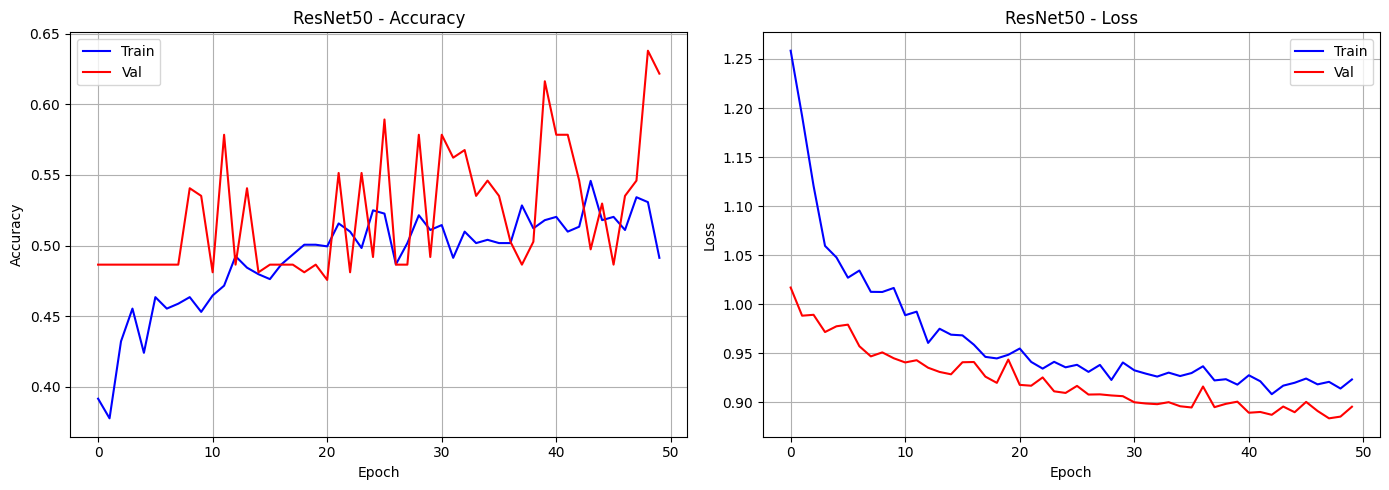

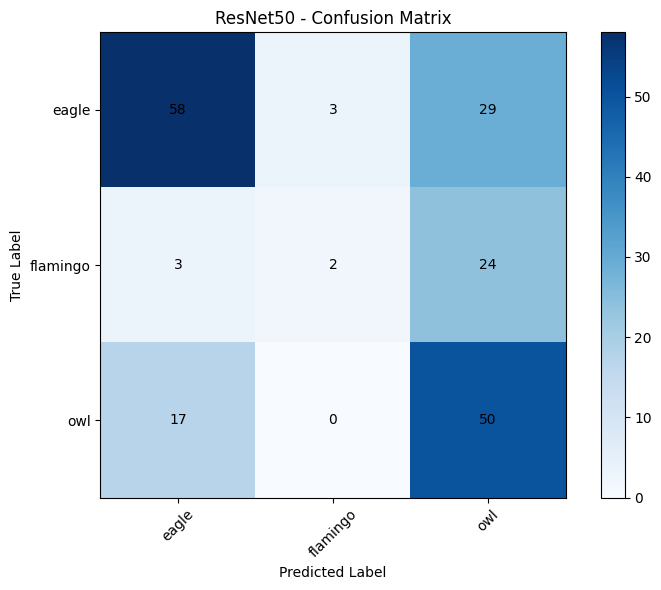


🚀 Training DenseNet121...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameters: 7,563,843
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 219s 7s/step - accuracy: 0.4565 - loss: 1.1420 - val_accuracy: 0.7676 - val_loss: 0.5783
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.7092 - loss: 0.6739 - val_accuracy: 0.8486 - val_loss: 0.4005
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 190s 7s/step - accuracy: 0.7937 - loss: 0.4949 - val_accuracy: 0.8649 - val_loss: 0.3564
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 194s 7s/step - accuracy: 0.8401 - loss: 0.4110 - val_accuracy: 0.8757 - val_loss: 0.3096
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 200s 7s/step - accuracy: 0.8598 - loss: 0.3823 - val_accuracy: 0.8919 - val_loss: 0.2836
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 196s 7s/step - accuracy: 0.8552 - loss: 0.3416 - val_accuracy: 0.8919 - val_loss: 0.2813
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 195s 7s/step - accuracy: 0.8795 - loss: 0.3075 - val_accuracy: 0.9135 - val_loss: 0.2519
Epoch 8/50


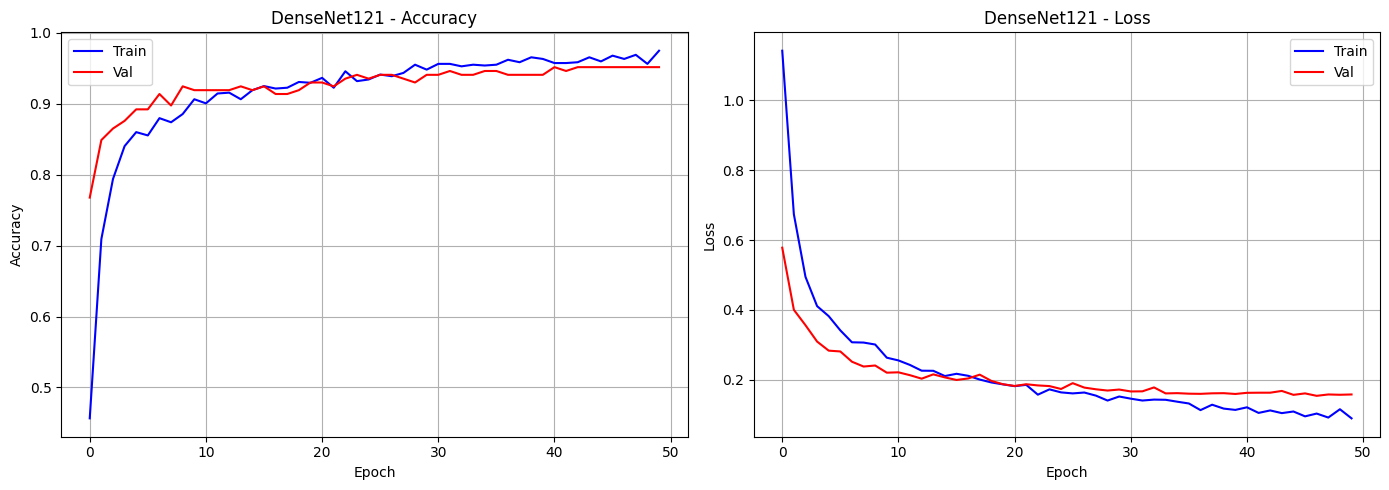

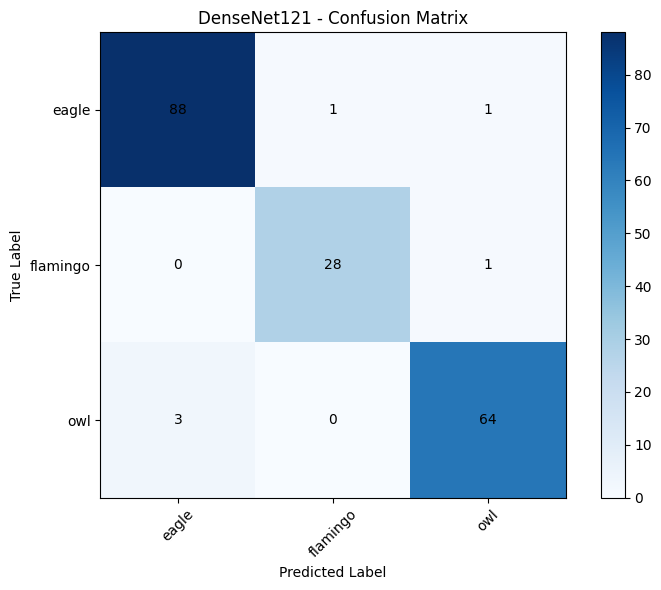


🚀 Training MobileNetV3...
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameters: 3,489,923
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.3905 - loss: 1.1640 - val_accuracy: 0.4865 - val_loss: 1.0069
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4415 - loss: 1.1175 - val_accuracy: 0.4865 - val_loss: 1.0098
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4322 - loss: 1.1257 - val_accuracy: 0.4865 - val_loss: 0.9980
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.3963 - loss: 1.1131 - val_accuracy: 0.4865 - val_loss: 0.9972
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4426 - loss: 1.0729 - val_accuracy: 0.4865 - val_loss: 0.9922
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4299 - loss: 1.0739 - val_accuracy: 0.4865 - val_loss: 0.9897
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4276 - loss: 1.0783 - val_accuracy: 0.4865 - val_loss: 0.9875
Epoch 8/50
27/27 ━

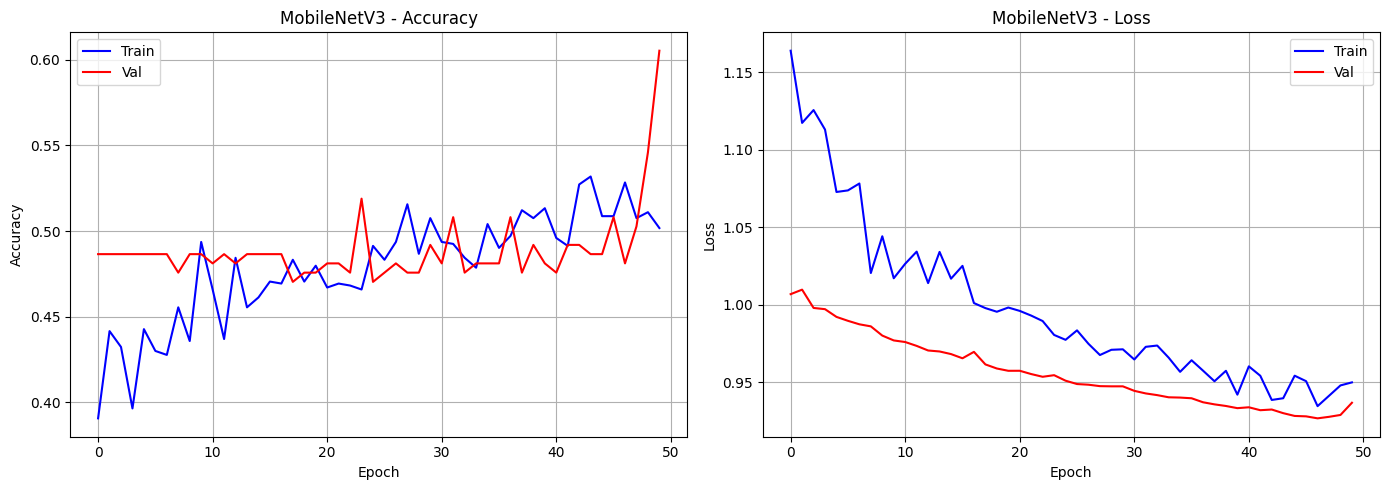

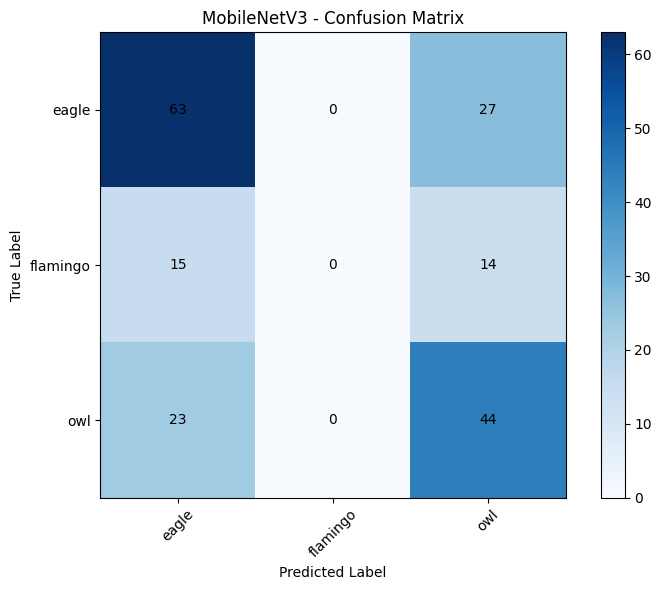



🏆 FINAL COMPARISON TABLE
Model                Accuracy     mAP          Time (min)   Parameters  
----------------------------------------------------------------------
ResNet50             0.5914       0.5430       165.23       24,638,339  
DenseNet121          0.9677       0.9674       163.86       7,563,843   
MobileNetV3          0.5753       0.3805       51.94        3,489,923   

✅ BEST MODEL: DenseNet121
   Accuracy: 0.9677
   mAP: 0.9674

✅ Training complete! Download the PNG files from the left panel.


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, precision_score
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# ============= CORRECT PATH =============
DATA_PATH = '/content/drive/My Drive/BirdDataset/BirdDataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

print("="*60)
print("🐦 BIRD SPECIES CLASSIFICATION")
print("="*60)
print(f"Path: {DATA_PATH}")
print(f"Epochs: {EPOCHS}")
print("="*60)

# Verify only eagle, flamingo, owl exist
print("\n✅ Using ONLY these 3 classes:")
for folder in ['eagle', 'flamingo', 'owl']:
    folder_path = os.path.join(DATA_PATH, folder)
    if os.path.exists(folder_path):
        count = len(os.listdir(folder_path))
        print(f"   {folder}: {count} images")

# ============= CREATE 3-CLASS ONLY DATASET =============
# Create a temporary folder structure with only 3 classes
!mkdir -p /content/temp_bird_data/train
!mkdir -p /content/temp_bird_data/val
!mkdir -p /content/temp_bird_data/test

import shutil
from sklearn.model_selection import train_test_split

# Get all images for each class
all_images = []
all_labels = []

class_mapping = {'eagle': 0, 'flamingo': 1, 'owl': 2}
class_names = ['eagle', 'flamingo', 'owl']

for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    if os.path.exists(class_path):
        images = [os.path.join(class_path, img) for img in os.listdir(class_path)
                 if img.endswith(('.jpg', '.jpeg', '.png'))]
        all_images.extend(images)
        all_labels.extend([class_mapping[class_name]] * len(images))
        print(f"✅ {class_name}: {len(images)} images")

# Split into train (70%), val (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n📊 Split results:")
print(f"   Training: {len(X_train)} images")
print(f"   Validation: {len(X_val)} images")
print(f"   Testing: {len(X_test)} images")

# Copy files to temp folder
def copy_files_to_folder(file_list, label_list, dest_folder):
    for file_path, label in zip(file_list, label_list):
        class_folder = os.path.join(dest_folder, class_names[label])
        os.makedirs(class_folder, exist_ok=True)
        dest_path = os.path.join(class_folder, os.path.basename(file_path))
        if not os.path.exists(dest_path):
            shutil.copy2(file_path, dest_path)

copy_files_to_folder(X_train, y_train, '/content/temp_bird_data/train')
copy_files_to_folder(X_val, y_val, '/content/temp_bird_data/val')
copy_files_to_folder(X_test, y_test, '/content/temp_bird_data/test')

print("\n✅ Data prepared in /content/temp_bird_data/")

# ============= DATA LOADING =============
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/temp_bird_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/temp_bird_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/temp_bird_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"\n✅ Classes: {class_names}")
print(f"✅ Training: {train_gen.samples} images")
print(f"✅ Validation: {val_gen.samples} images")
print(f"✅ Testing: {test_gen.samples} images")

# ============= CREATE MODEL FUNCTION =============
def create_model(base_model_fn):
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ============= CALCULATE mAP =============
def calculate_map(model, generator):
    generator.reset()
    y_true = generator.classes
    y_pred = model.predict(generator, verbose=0)
    y_pred_class = np.argmax(y_pred, axis=1)
    return np.mean(precision_score(y_true, y_pred_class, average=None, zero_division=0))

# ============= PLOT FUNCTIONS =============
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], 'b-', label='Train')
    axes[0].plot(history.history['val_accuracy'], 'r-', label='Val')
    axes[0].set_title(f'{name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], 'b-', label='Train')
    axes[1].plot(history.history['val_loss'], 'r-', label='Val')
    axes[1].set_title(f'{name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{name}_history.png')
    plt.show()

def plot_confusion(model, generator, name):
    generator.reset()
    y_true = generator.classes
    y_pred = model.predict(generator, verbose=0)
    y_pred_class = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_true, y_pred_class)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{name}_confusion_matrix.png')
    plt.show()

# ============= TRAIN MODELS =============
models = [
    ('ResNet50', ResNet50),
    ('DenseNet121', DenseNet121),
    ('MobileNetV3', lambda **kw: MobileNetV3Large(**kw))
]

results = {}

for name, model_fn in models:
    print(f"\n{'='*50}")
    print(f"🚀 Training {name}...")
    print(f"{'='*50}")

    model = create_model(model_fn)
    print(f"Parameters: {model.count_params():,}")

    start = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, verbose=1)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    mAP = calculate_map(model, test_gen)

    results[name] = {
        'accuracy': test_acc,
        'mAP': mAP,
        'time': train_time,
        'params': model.count_params()
    }

    print(f"\n📊 {name} Results:")
    print(f"   Accuracy: {test_acc:.4f}")
    print(f"   mAP: {mAP:.4f}")
    print(f"   Time: {train_time/60:.2f} min")

    plot_history(history, name)
    plot_confusion(model, test_gen, name)

# ============= FINAL COMPARISON =============
print("\n")
print("="*70)
print("🏆 FINAL COMPARISON TABLE")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<12} {'mAP':<12} {'Time (min)':<12} {'Parameters':<12}")
print("-"*70)

for name, res in results.items():
    print(f"{name:<20} {res['accuracy']:<12.4f} {res['mAP']:<12.4f} {res['time']/60:<12.2f} {res['params']:<12,}")

best = max(results, key=lambda x: results[x]['accuracy'])
print("\n" + "="*70)
print(f"✅ BEST MODEL: {best}")
print(f"   Accuracy: {results[best]['accuracy']:.4f}")
print(f"   mAP: {results[best]['mAP']:.4f}")
print("="*70)

print("\n✅ Training complete! Download the PNG files from the left panel.")